In [1]:
%pip install pandas numpy matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def plot_water_consumption(
    excel_file,
    datetime_col=None,
    consumption_col=None,
    sheet_name=0
):
    """
    Visualize water consumption for one customer.

    Parameters
    ----------
    excel_file : str
        Path to Excel file

    datetime_col : str
        Timestamp column name.
        If None, first column is used.

    consumption_col : str
        Consumption column name.
        If None, second column is used.

    sheet_name : int or str
        Excel sheet
    """

    # -----------------------------
    # Read Excel
    # -----------------------------
    df = pd.read_excel(
        excel_file,
        header=2,
        sheet_name=sheet_name
    )

    if datetime_col is None:
        datetime_col = df.columns[0]

    if consumption_col is None:
        consumption_col = df.columns[1]

    df = df[[datetime_col, consumption_col]].copy()

    df.columns = ["Timestamp", "Consumption"]

    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

    df = df.sort_values("Timestamp")

    df.reset_index(drop=True, inplace=True)

    # -----------------------------------
    # Additional columns
    # -----------------------------------

    df["Date"] = df["Timestamp"].dt.date
    df["Hour"] = df["Timestamp"].dt.hour + 1

    df["Week"] = (
        (df["Timestamp"] - df["Timestamp"].min())
        .dt.days // 7
    ) + 1

    df["Month"] = (
        (df["Timestamp"].dt.year - df["Timestamp"].dt.year.min()) * 12
        + df["Timestamp"].dt.month
    )

    df["Month"] = (
        df["Month"] - df["Month"].min() + 1
    )

    df["Weekday"] = df["Timestamp"].dt.day_name()
    df["Weekend"] = df["Timestamp"].dt.weekday >= 5

    # ============================================
    # 1 DAY (Second Complete Day)
    # ============================================

    unique_dates = sorted(df["Date"].unique())

    if len(unique_dates) < 2:
        raise ValueError("Dataset does not contain at least two unique dates.")

    second_day = unique_dates[1]

    day_df = df[df["Date"] == second_day]

    plt.figure(figsize=(18,5))

    plt.plot(
        day_df["Hour"],
        day_df["Consumption"],
        marker="o",
        linewidth=2,
        markersize=5
    )

    plt.xlim(1, 24)
    plt.xticks(range(1, 25))

    plt.xlabel("Hour")
    plt.ylabel("Consumption (m³)")
    plt.title(f"Water Consumption - {second_day}")

    plt.grid(True, which="major", alpha=0.7)
    plt.grid(True, which="minor", linestyle=":", alpha=0.4)
    plt.minorticks_on()

    plt.tight_layout()
    plt.show()

    # ============================================
    # 1 WEEK
    # ============================================

    week_df = df[df["Week"] == 1]

    plt.figure(figsize=(14,5))

    colors = plt.cm.tab10.colors

    for i, (day, group) in enumerate(week_df.groupby("Date")):

        plt.plot(
            group["Hour"],
            group["Consumption"],
            label=str(day),
            color=colors[i % len(colors)]
        )

    plt.xticks(range(1,25))
    plt.xlabel("Hour")
    plt.ylabel("Consumption (m³)")
    plt.title("Water Consumption - First Week")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ============================================
    # 1 MONTH
    # ============================================

    month_df = df[df["Month"] == 1]

    plt.figure(figsize=(14,5))

    colors = plt.cm.tab20.colors

    for week, group in month_df.groupby("Week"):

        hourly = group.groupby("Hour")["Consumption"].mean()

        plt.plot(
            hourly.index,
            hourly.values,
            label=f"Week {week}",
            color=colors[(week-1) % len(colors)]
        )

    plt.xticks(range(1,25))
    plt.xlabel("Hour")
    plt.ylabel("Consumption (m³)")
    plt.title("Water Consumption - First Month")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ============================================
    # ENTIRE DATASET
    # ============================================

    plt.figure(figsize=(15,5))

    colors = plt.cm.tab20.colors

    for month, group in df.groupby("Month"):

        hourly = group.groupby("Hour")["Consumption"].mean()

        plt.plot(
            hourly.index,
            hourly.values,
            label=f"Month {month}",
            color=colors[(month-1) % len(colors)]
        )

    plt.xticks(range(1,25))
    plt.xlabel("Hour")
    plt.ylabel("Consumption (m³)")
    plt.title("Water Consumption - Entire Dataset")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ============================================
    # WEEKDAY VS WEEKEND
    # ============================================

    plt.figure(figsize=(12,5))

    weekday = (
        df[~df["Weekend"]]
        .groupby("Hour")["Consumption"]
        .mean()
    )

    weekend = (
        df[df["Weekend"]]
        .groupby("Hour")["Consumption"]
        .mean()
    )

    plt.plot(
        weekday.index,
        weekday.values,
        linewidth=2,
        label="Weekday"
    )

    plt.plot(
        weekend.index,
        weekend.values,
        linewidth=2,
        label="Weekend"
    )

    plt.xticks(range(1,25))
    plt.xlabel("Hour")
    plt.ylabel("Consumption (m³)")
    plt.title("Weekday vs Weekend")
    plt.legend()
    plt.grid(True)
    plt.show()

    return df

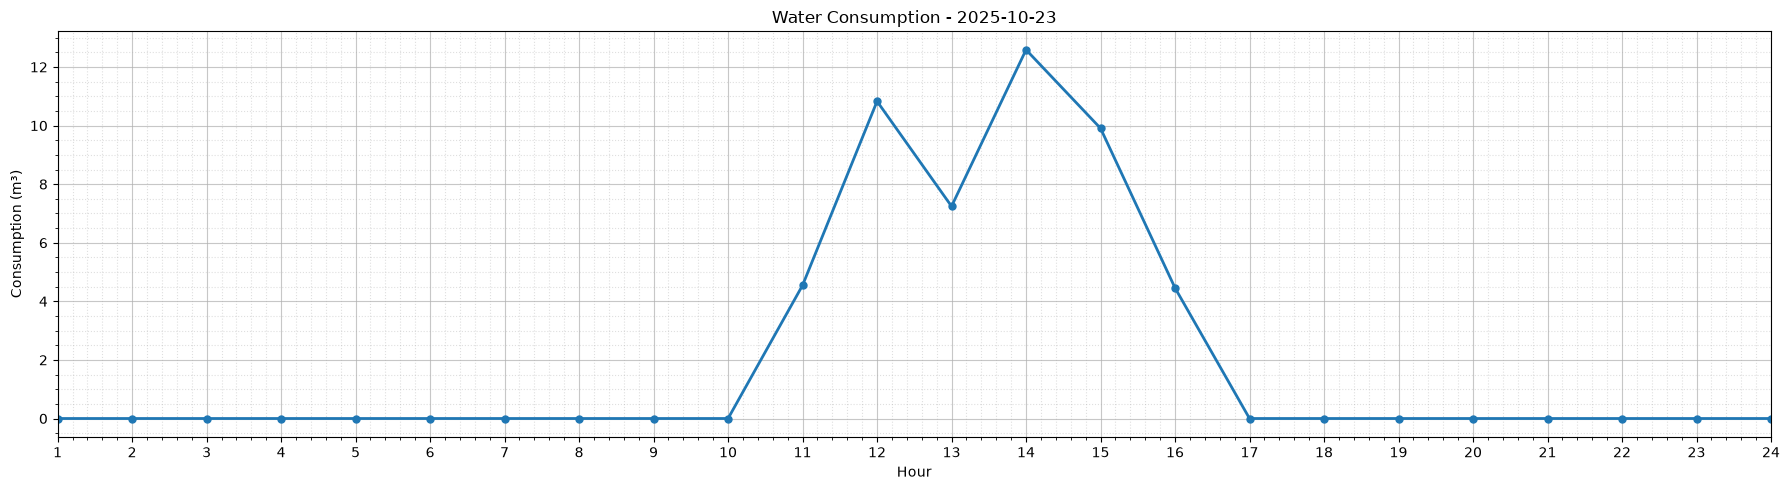

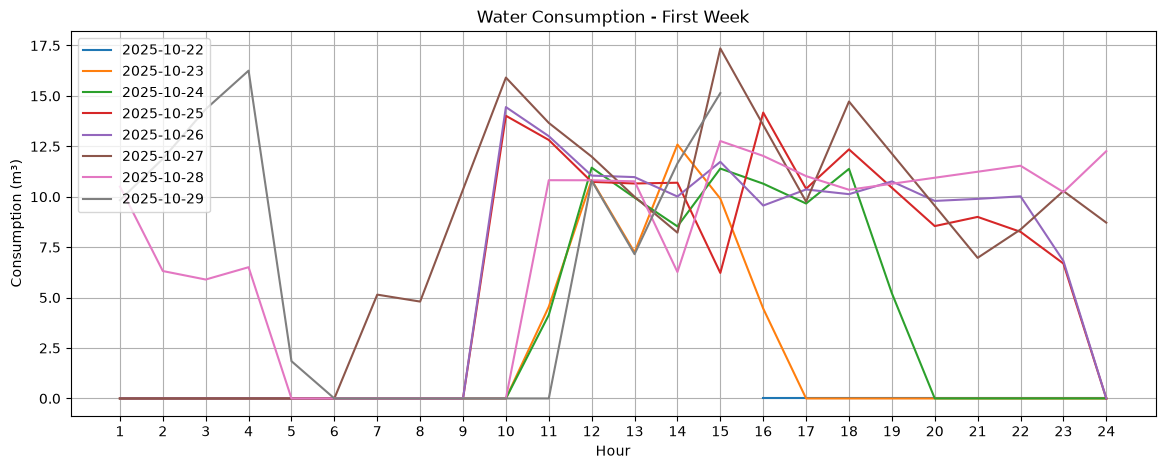

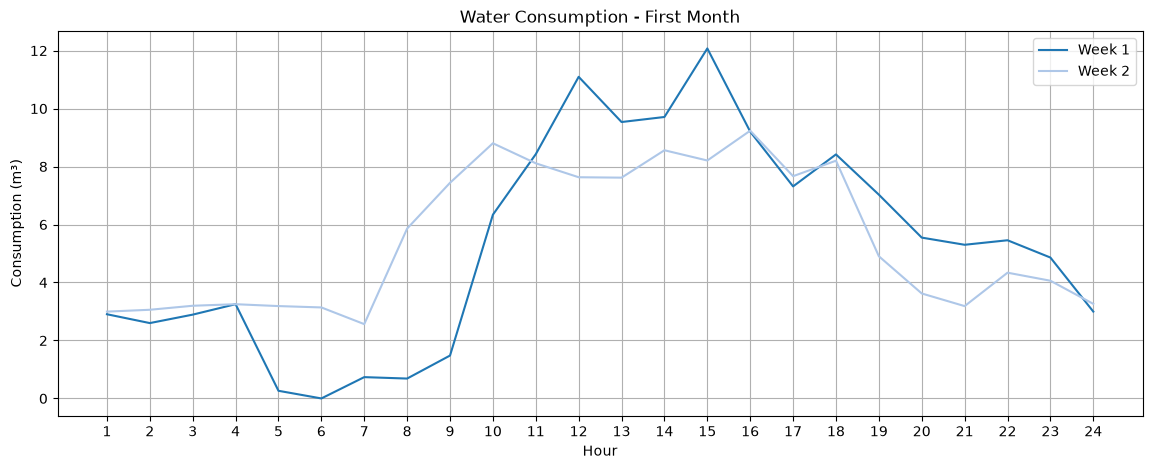

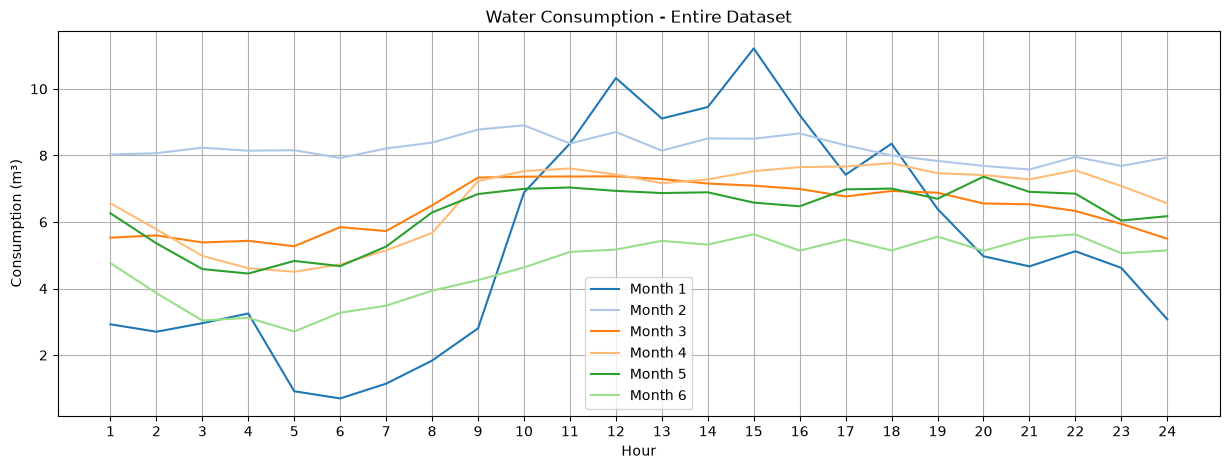

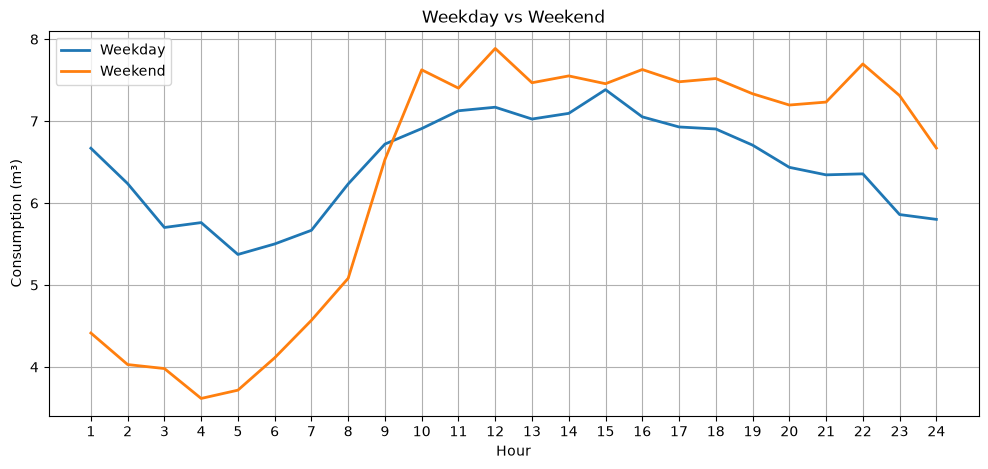

,Timestamp,Consumption,Date,Hour,Week,Month,Weekday,Weekend
0,2025-10-22 15:00:00,0.000,2025-10-22,16,1,1,Wednesday,False
1,2025-10-22 16:00:00,0.000,2025-10-22,17,1,1,Wednesday,False
2,2025-10-22 17:00:00,0.000,2025-10-22,18,1,1,Wednesday,False
3,2025-10-22 18:00:00,0.000,2025-10-22,19,1,1,Wednesday,False
4,2025-10-22 19:00:00,0.000,2025-10-22,20,1,1,Wednesday,False
...,...,...,...,...,...,...,...,...
3366,2026-03-29 19:00:00,7.691,2026-03-29,20,23,6,Sunday,True
3367,2026-03-29 20:00:00,7.217,2026-03-29,21,23,6,Sunday,True
3368,2026-03-29 21:00:00,7.227,2026-03-29,22,23,6,Sunday,True
3369,2026-03-29 22:00:00,7.478,2026-03-29,23,23,6,Sunday,True


In [4]:
plot_water_consumption("datasets/RashidNasser-103122.xlsx")

In [5]:
def plot_selected_months(df, months=[1, 3, 6]):
    """
    Plot the average hourly water consumption for selected months.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame returned by plot_water_consumption()

    months : list
        List of month numbers to plot (default: [1, 3, 6])
    """

    plt.figure(figsize=(15,5))

    colors = plt.cm.tab10.colors

    plotted = 0

    for i, month in enumerate(months):

        month_df = df[df["Month"] == month]

        if month_df.empty:
            print(f"Month {month} not found in dataset.")
            continue

        hourly = (
            month_df.groupby("Hour")["Consumption"]
            .mean()
        )

        plt.plot(
            hourly.index,
            hourly.values,
            linewidth=2,
            label=f"Month {month}",
            color=colors[i % len(colors)]
        )

        plotted += 1

    if plotted == 0:
        print("None of the selected months exist in the dataset.")
        return

    plt.xticks(range(1,25))
    plt.xlim(1,24)

    plt.xlabel("Hour")
    plt.ylabel("Consumption (m³)")
    plt.title("Water Consumption - Selected Months")

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

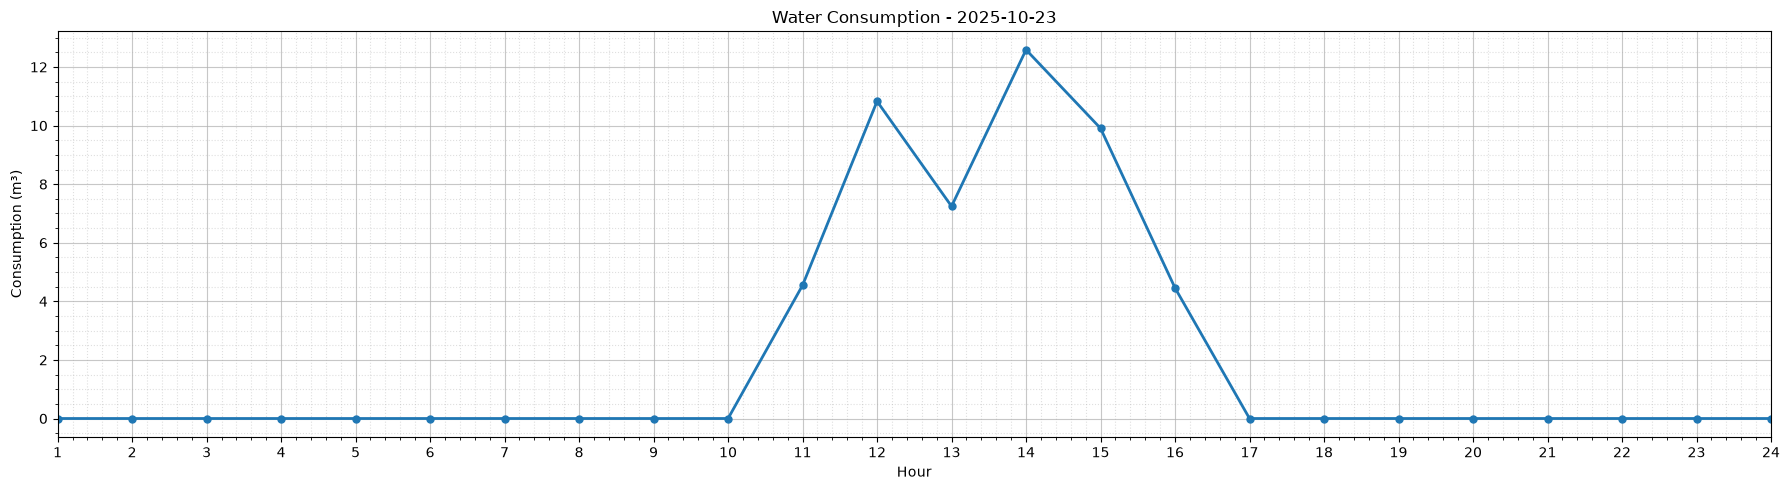

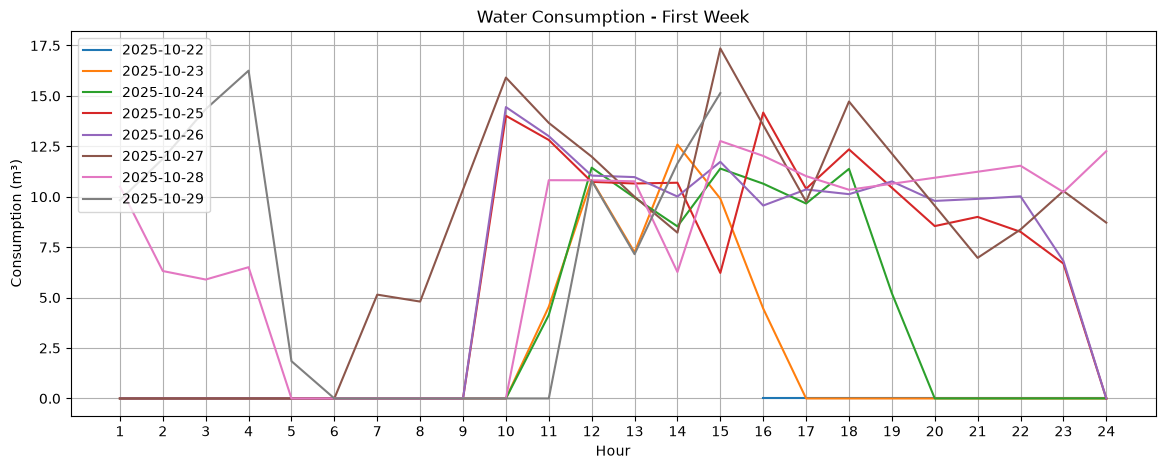

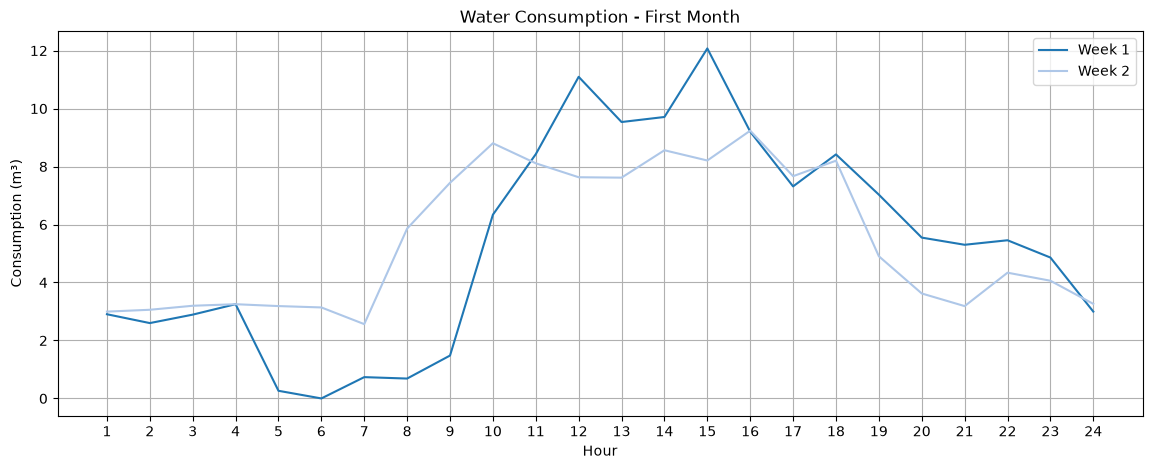

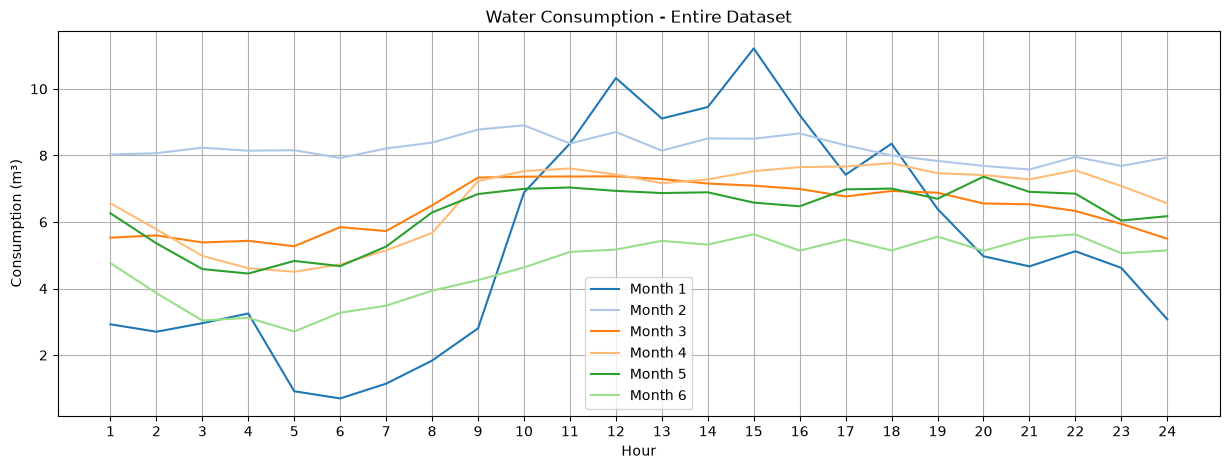

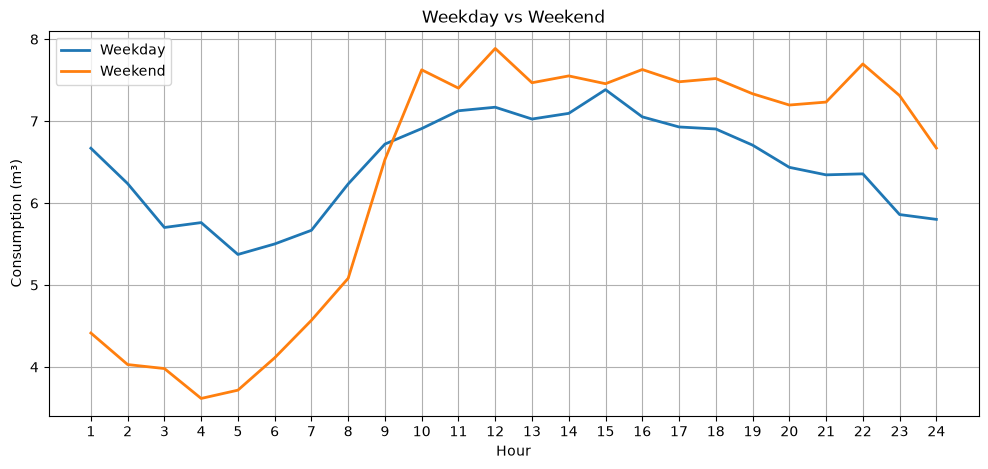

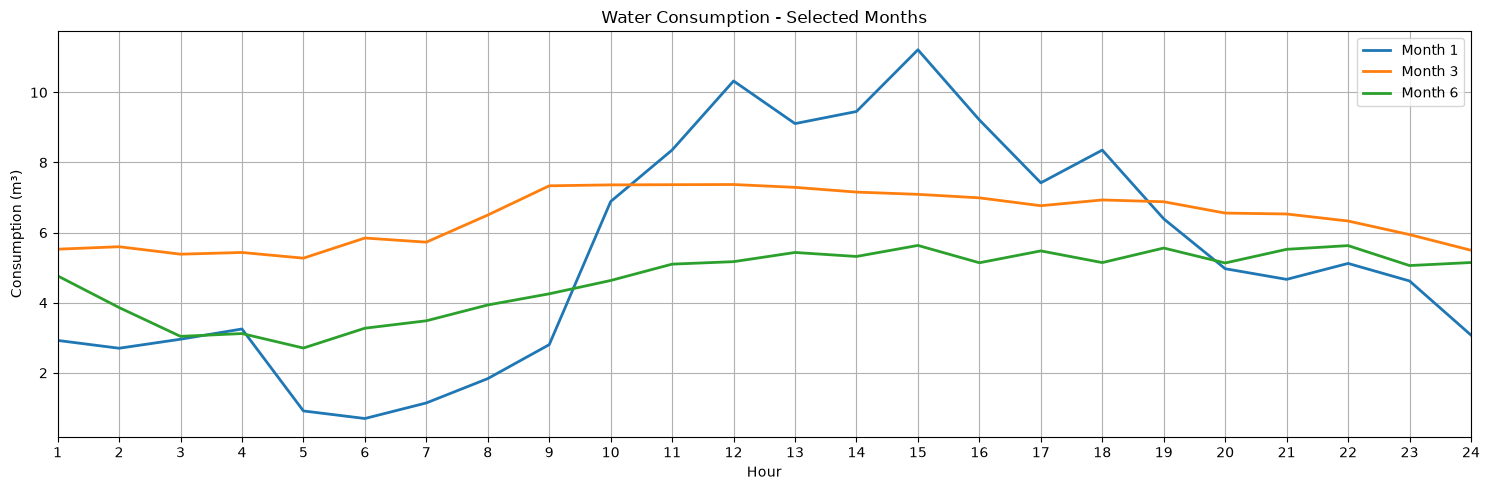

In [7]:
df = plot_water_consumption("datasets/RashidNasser-103122.xlsx")

plot_selected_months(df)

In [8]:
def plot_water_patterns(df):
    """
    Plot water consumption patterns from the dataframe created in
    plot_water_consumption().

    Required columns:
        Timestamp
        Consumption
        Hour
        Date
        Week
        Month
        Weekend
    """

    # ==========================================
    # Average Hourly Consumption
    # ==========================================

    hourly = (
        df.groupby("Hour")["Consumption"]
        .mean()
    )

    plt.figure(figsize=(12,4))
    plt.plot(hourly.index, hourly.values, linewidth=2)
    plt.xticks(range(1,25))
    plt.xlabel("Hour")
    plt.ylabel("Consumption (m³)")
    plt.title("Average Hourly Consumption")
    plt.grid(True)
    plt.show()


    # ==========================================
    # Daily Total Consumption
    # ==========================================

    daily = (
        df.groupby("Date")["Consumption"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(14,4))
    plt.plot(
        range(1, len(daily)+1),
        daily["Consumption"],
        linewidth=2
    )

    plt.xticks(
        range(
            1,
            len(daily)+1,
            max(1, len(daily)//10)
        )
    )

    plt.xlabel("Day")
    plt.ylabel("Consumption (m³)")
    plt.title("Daily Water Consumption")
    plt.grid(True)
    plt.show()


    # ==========================================
    # Weekly Total Consumption
    # ==========================================

    weekly = (
        df.groupby("Week")["Consumption"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(12,4))

    colors = plt.cm.tab20.colors

    plt.bar(
        weekly["Week"],
        weekly["Consumption"],
        color=[colors[(i-1)%20] for i in weekly["Week"]]
    )

    plt.xticks(weekly["Week"])
    plt.xlabel("Week")
    plt.ylabel("Consumption (m³)")
    plt.title("Weekly Water Consumption")
    plt.grid(axis='y')
    plt.show()


    # ==========================================
    # Monthly Total Consumption
    # ==========================================

    monthly = (
        df.groupby("Month")["Consumption"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(10,4))

    plt.bar(
        monthly["Month"],
        monthly["Consumption"],
        color=plt.cm.Set2.colors[:len(monthly)]
    )

    plt.xticks(monthly["Month"])
    plt.xlabel("Month")
    plt.ylabel("Consumption (m³)")
    plt.title("Monthly Water Consumption")
    plt.grid(axis='y')
    plt.show()


    # ==========================================
    # Hourly Heatmap
    # ==========================================

    heatmap = (
        df.pivot_table(
            values="Consumption",
            index="Date",
            columns="Hour",
            aggfunc="sum"
        )
    )

    plt.figure(figsize=(14,8))

    plt.imshow(
        heatmap,
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(label="Consumption (m³)")

    plt.xticks(
        range(24),
        range(1,25)
    )

    plt.yticks(
        range(len(heatmap.index)),
        range(1, len(heatmap.index)+1)
    )

    plt.xlabel("Hour")
    plt.ylabel("Day")
    plt.title("Hourly Consumption Heatmap")

    plt.show()


    # ==========================================
    # Overnight Consumption (Leakage Indicator)
    # ==========================================

    overnight = df[
        (df["Hour"] >= 1) &
        (df["Hour"] <= 5)
    ]

    overnight_daily = (
        overnight.groupby("Date")["Consumption"]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(14,4))

    plt.plot(
        range(1, len(overnight_daily)+1),
        overnight_daily["Consumption"],
        linewidth=2
    )

    plt.xticks(
        range(
            1,
            len(overnight_daily)+1,
            max(1, len(overnight_daily)//10)
        )
    )

    plt.xlabel("Day")
    plt.ylabel("Consumption (m³)")
    plt.title("Average Overnight Consumption (1 AM - 5 AM)")
    plt.grid(True)
    plt.show()

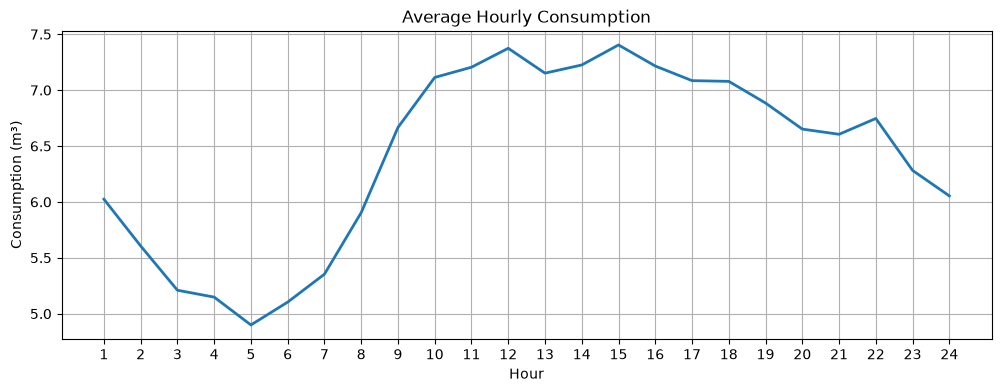

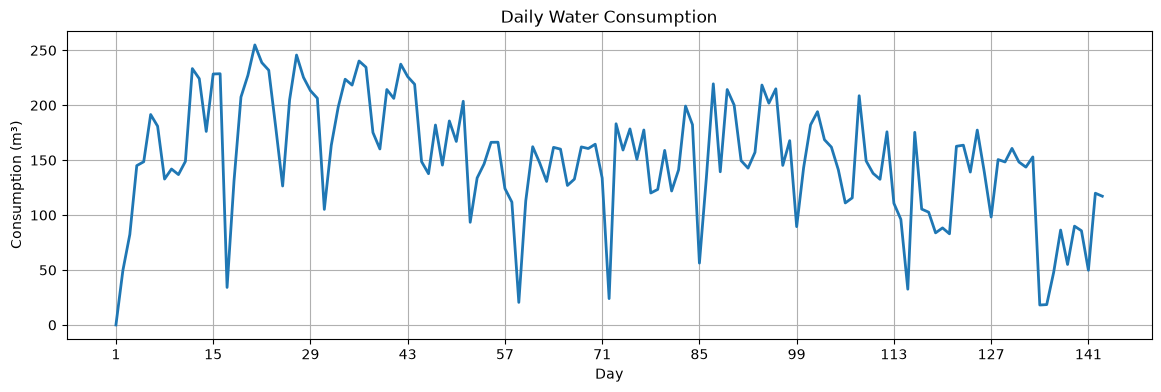

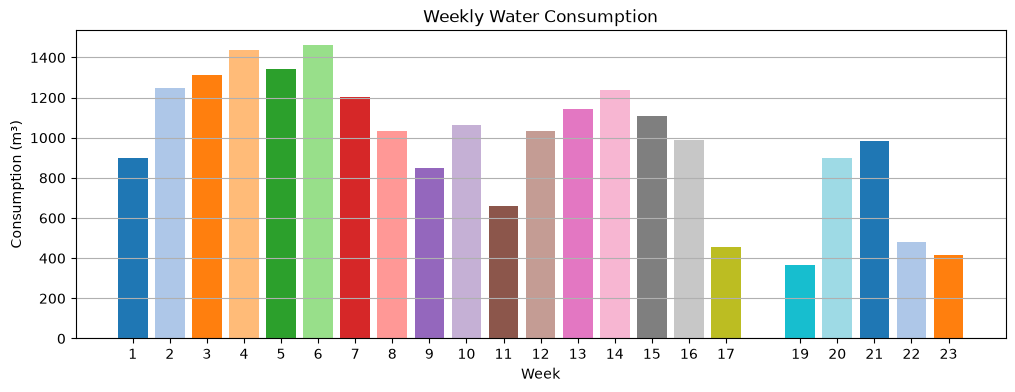

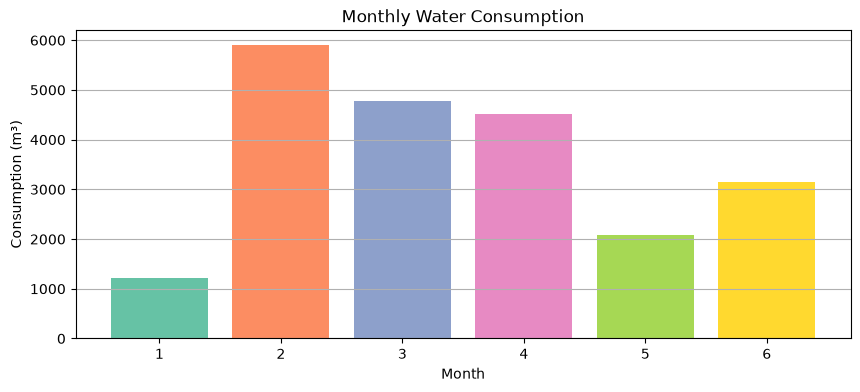

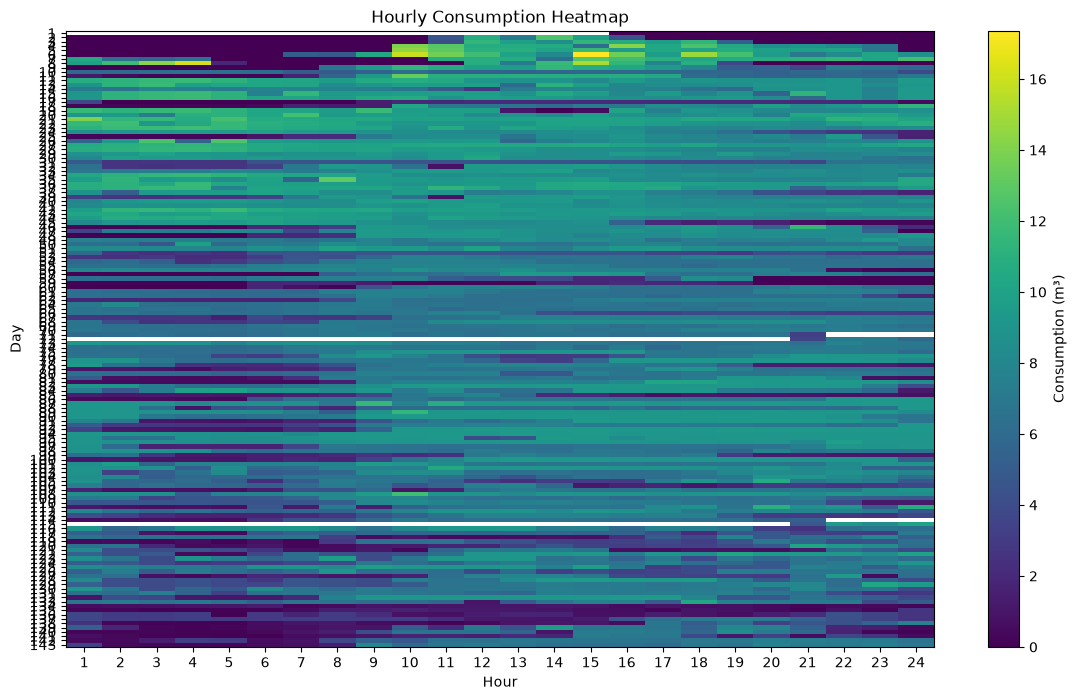

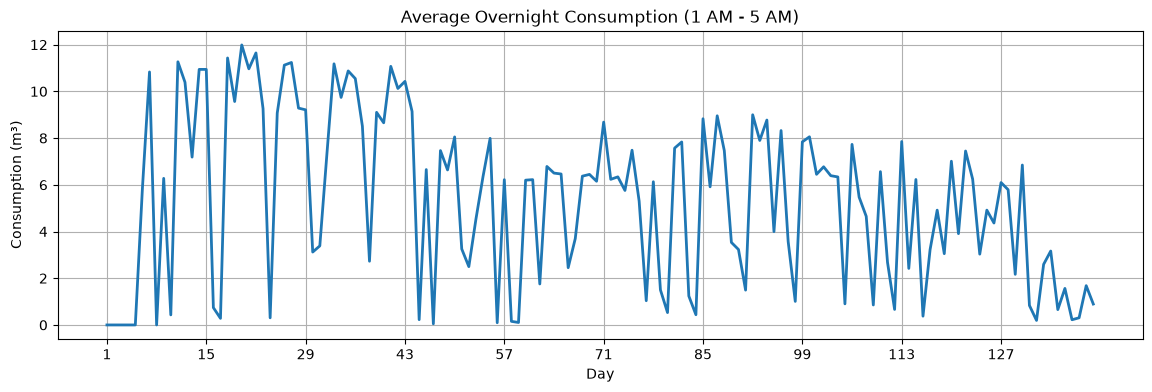

In [9]:
plot_water_patterns(df)